# Prédiction du Turnover des Employés — Notebook 2
## Préparation des données & Étude comparative de modèles

**Projet Capstone M2 — Jebari Oussema**
Dataset : IBM HR Analytics Employee Attrition (1 470 employés, 35 variables)

---

Ce notebook couvre :
1. La préparation des données (nettoyage, encodage, split train/test)
2. La gestion du déséquilibre des classes avec SMOTE (sur le train uniquement)
3. L'entraînement et l'évaluation comparative de 3 modèles : Logistic Regression, Random Forest, XGBoost
4. Un tableau comparatif final et des courbes ROC
5. Une synthèse indiquant le meilleur modèle et pourquoi

**Rappel important** : le dataset est déséquilibré (~16% de départs). L'accuracy seule n'est pas un indicateur fiable :
on accordera une attention particulière au **F1-score** et au **recall de la classe minoritaire (Attrition = Yes)**.

---
## ÉTAPE 0 — Setup de l'environnement

In [1]:
# Import des librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
from imblearn.over_sampling import SMOTE

# Graine aléatoire fixée partout pour la reproductibilité
RANDOM_STATE = 42

# Configuration de l'affichage
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print('Librairies importées avec succès !')

Librairies importées avec succès !


---
## ÉTAPE 1 — Préparation des données

### 1.1 Chargement du dataset

In [2]:
# Chargement du fichier CSV depuis le dossier data/
df = pd.read_csv('../data/WA_Fn-UseC_-HR-Employee-Attrition.csv')

print(f'Dimensions initiales : {df.shape[0]} lignes x {df.shape[1]} colonnes')
df.head()

Dimensions initiales : 1470 lignes x 35 colonnes


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


### 1.2 Suppression des colonnes inutiles

On supprime :
- **`EmployeeCount`**, **`Over18`**, **`StandardHours`** : colonnes constantes (une seule valeur unique, aucune information)
- **`EmployeeNumber`** : identifiant unique de l'employé, sans valeur prédictive

In [3]:
# Suppression des colonnes constantes + de l'identifiant
colonnes_a_supprimer = ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
df = df.drop(columns=colonnes_a_supprimer)

print(f'Colonnes supprimées : {colonnes_a_supprimer}')
print(f'Dimensions après suppression : {df.shape[0]} lignes x {df.shape[1]} colonnes')

Colonnes supprimées : ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
Dimensions après suppression : 1470 lignes x 31 colonnes


### 1.3 Encodage de la variable cible (Attrition)

On transforme la variable cible textuelle en valeur numérique : `Yes` → 1 (départ), `No` → 0 (reste).

In [4]:
# Encodage binaire de la cible
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

print('Répartition de la variable cible après encodage :')
print(df['Attrition'].value_counts())
print('\nRépartition en pourcentage :')
print((df['Attrition'].value_counts(normalize=True) * 100).round(2))

Répartition de la variable cible après encodage :
Attrition
0    1233
1     237
Name: count, dtype: int64

Répartition en pourcentage :
Attrition
0    83.88
1    16.12
Name: proportion, dtype: float64


### 1.4 Encodage des variables catégorielles (One-Hot Encoding)

Les variables catégorielles restantes (texte) sont transformées en variables numériques binaires via
`pd.get_dummies`. L'option `drop_first=True` supprime une catégorie de référence par variable afin
d'éviter la colinéarité parfaite (utile notamment pour la régression logistique).

In [5]:
# Identification des variables catégorielles restantes (hors cible, déjà encodée)
colonnes_categorielles = df.select_dtypes(include='object').columns.tolist()
print(f'Variables catégorielles à encoder ({len(colonnes_categorielles)}) :')
print(colonnes_categorielles)

# One-Hot Encoding
df_encode = pd.get_dummies(df, columns=colonnes_categorielles, drop_first=True)

print(f'\nDimensions après encodage : {df_encode.shape[0]} lignes x {df_encode.shape[1]} colonnes')
df_encode.head()

Variables catégorielles à encoder (7) :


['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Dimensions après encodage : 1470 lignes x 45 colonnes


,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Research & Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,Gender_Male,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,2,94,3,2,4,5993,19479,8,11,3,1,0,8,0,1,6,4,0,5,False,True,False,True,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,True
1,49,0,279,8,1,3,61,2,2,2,5130,24907,1,23,4,4,1,10,3,3,10,7,1,7,True,False,True,False,True,False,False,False,False,True,False,False,False,False,False,True,False,False,True,False,False
2,37,1,1373,2,2,4,92,2,1,3,2090,2396,6,15,3,2,0,7,3,3,0,0,0,0,False,True,True,False,False,False,False,True,False,True,False,True,False,False,False,False,False,False,False,True,True
3,33,0,1392,3,4,4,56,3,1,3,2909,23159,1,11,3,3,0,8,3,3,8,7,3,0,True,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,True
4,27,0,591,2,1,1,40,3,1,2,3468,16632,9,12,3,4,1,6,3,3,2,2,2,2,False,True,True,False,False,False,True,False,False,True,False,True,False,False,False,False,False,False,True,False,False


### 1.5 Séparation X (variables explicatives) et y (cible)

In [6]:
# Séparation des variables explicatives (X) et de la variable cible (y)
X = df_encode.drop(columns=['Attrition'])
y = df_encode['Attrition']

print(f'X : {X.shape[0]} lignes, {X.shape[1]} variables explicatives')
print(f'y : {y.shape[0]} valeurs (cible)')

X : 1470 lignes, 44 variables explicatives
y : 1470 valeurs (cible)


### 1.6 Split train/test (80/20, stratifié)

La stratification (`stratify=y`) garantit que la proportion de départs (~16%) est préservée
à l'identique dans les ensembles d'entraînement et de test.

In [7]:
# Split train/test 80/20 stratifié sur la cible
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"Ensemble d'entraînement : {X_train.shape[0]} lignes ({X_train.shape[0] / len(X):.1%})")
print(f"Ensemble de test        : {X_test.shape[0]} lignes ({X_test.shape[0] / len(X):.1%})")

print("\nRépartition de la cible (train) :")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nRépartition de la cible (test) :")
print((y_test.value_counts(normalize=True) * 100).round(2))

Ensemble d'entraînement : 1176 lignes (80.0%)
Ensemble de test        : 294 lignes (20.0%)

Répartition de la cible (train) :
Attrition
0    83.84
1    16.16
Name: proportion, dtype: float64

Répartition de la cible (test) :
Attrition
0    84.01
1    15.99
Name: proportion, dtype: float64


### 1.7 Standardisation des variables numériques

La régression logistique est sensible à l'échelle des variables (ex : `MonthlyIncome` vs `Age`).
On applique un `StandardScaler` **ajusté uniquement sur le jeu d'entraînement** (pour éviter toute
fuite d'information depuis le jeu de test), puis appliqué aux deux ensembles.

In [8]:
# Standardisation (moyenne 0, écart-type 1)
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test), columns=X_test.columns, index=X_test.index
)

print('Standardisation effectuée (fit sur le train uniquement).')
X_train_scaled.head()

Standardisation effectuée (fit sur le train uniquement).


,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Research & Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,Gender_Male,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
1194,1.090194,1.049455,-0.899915,1.064209,-0.658710,-0.908436,1.795282,1.762189,-0.647997,2.026752,0.931289,1.330763,-0.337129,-0.432065,0.240218,2.613100,2.261482,-0.605389,0.337621,-0.665706,-0.625365,-0.368024,-0.616406,-0.486408,0.648298,-1.361752,1.493576,1.206281,-0.358607,-0.669534,-0.235914,-0.329224,-1.221280,-0.190061,-0.472996,3.628867,-0.326041,-0.237915,-0.479714,-0.549841,-0.231869,-0.921443,-0.681548,-0.637729
128,-1.634828,-0.523449,-0.899915,-1.855332,0.260202,1.694111,0.373564,-0.986265,1.153526,-0.864408,0.682742,-1.083704,-0.337129,-0.432065,0.240218,0.247430,-1.072675,-0.605389,0.337621,-0.830071,-0.905635,-0.056884,-0.897047,-0.486408,0.648298,0.734348,-0.669534,-0.828994,-0.358607,-0.669534,-0.235914,3.037447,0.818813,-0.190061,2.114182,-0.275568,-0.326041,-0.237915,-0.479714,-0.549841,-0.231869,1.085255,-0.681548,-0.637729
810,0.981193,-0.992080,-0.777610,-1.855332,-1.577622,-0.662913,0.373564,1.762189,0.252765,2.347706,0.167705,0.123529,-0.880974,-0.432065,1.160403,0.247430,1.492061,0.190962,0.337621,0.813578,1.336527,0.565398,1.348076,-0.486408,0.648298,-1.361752,1.493576,-0.828994,2.788569,-0.669534,-0.235914,-0.329224,0.818813,-0.190061,-0.472996,3.628867,-0.326041,-0.237915,-0.479714,-0.549841,-0.231869,1.085255,-0.681548,-0.637729
478,-1.307825,-0.453653,0.445433,-1.855332,-0.658710,-1.252169,0.373564,-0.986265,0.252765,-0.956202,1.667056,-0.681293,-1.152896,-0.432065,0.240218,-0.935405,-0.559727,-1.401740,0.337621,-0.008246,-0.064824,-0.679165,0.506155,-0.486408,0.648298,-1.361752,1.493576,-0.828994,-0.358607,1.493576,-0.235914,-0.329224,0.818813,-0.190061,-0.472996,-0.275568,-0.326041,-0.237915,-0.479714,-0.549841,4.312772,1.085255,-0.681548,-0.637729
491,0.654191,0.491086,-0.043784,2.037390,1.179114,0.319180,0.373564,-0.070114,0.252765,-0.185956,0.728362,0.123529,-0.609051,-0.432065,-0.679966,0.247430,-0.175017,0.190962,0.337621,0.156119,0.775986,0.565398,0.786795,2.055886,-1.542501,0.734348,-0.669534,-0.828994,-0.358607,1.493576,-0.235914,-0.329224,0.818813,-0.190061,2.114182,-0.275568,-0.326041,-0.237915,-0.479714,-0.549841,-0.231869,-0.921443,-0.681548,1.568064


---
## ÉTAPE 2 — Gestion du déséquilibre des classes (SMOTE)

Le dataset d'entraînement est déséquilibré (~16% de la classe `Attrition = Yes`).
On applique **SMOTE (Synthetic Minority Over-sampling Technique)** pour équilibrer les classes
**uniquement sur le jeu d'entraînement**. Le jeu de test reste inchangé et reflète la réalité du terrain.

In [9]:
# Répartition avant SMOTE
print("Répartition des classes AVANT SMOTE (jeu d'entraînement) :")
print(y_train.value_counts())

# Application de SMOTE sur le jeu d'entraînement uniquement
smote = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

# Répartition après SMOTE
print("\nRépartition des classes APRÈS SMOTE (jeu d'entraînement) :")
print(y_train_sm.value_counts())

print(f"\nNombre d'observations : {len(y_train)} -> {len(y_train_sm)}")

print("\nPour rappel, le jeu de TEST n'est PAS modifié (reste réaliste/déséquilibré) :")
print(y_test.value_counts())

Répartition des classes AVANT SMOTE (jeu d'entraînement) :
Attrition
0    986
1    190
Name: count, dtype: int64



Répartition des classes APRÈS SMOTE (jeu d'entraînement) :
Attrition
0    986
1    986
Name: count, dtype: int64

Nombre d'observations : 1176 -> 1972

Pour rappel, le jeu de TEST n'est PAS modifié (reste réaliste/déséquilibré) :
Attrition
0    247
1     47
Name: count, dtype: int64


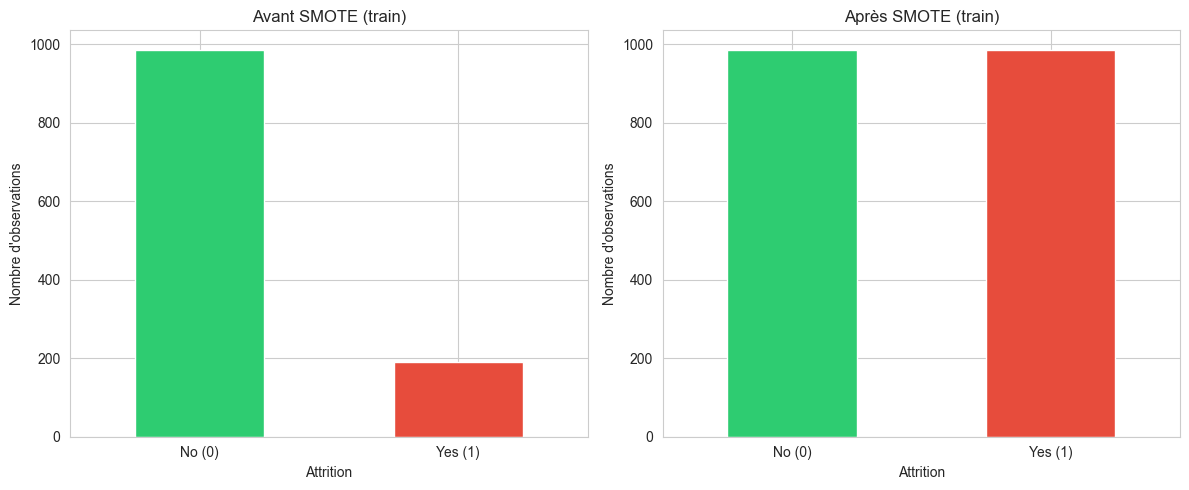

In [10]:
# Visualisation de la répartition des classes avant/après SMOTE
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

y_train.value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c']
)
axes[0].set_title('Avant SMOTE (train)')
axes[0].set_xticklabels(['No (0)', 'Yes (1)'], rotation=0)
axes[0].set_ylabel("Nombre d'observations")

y_train_sm.value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c']
)
axes[1].set_title('Après SMOTE (train)')
axes[1].set_xticklabels(['No (0)', 'Yes (1)'], rotation=0)
axes[1].set_ylabel("Nombre d'observations")

plt.tight_layout()
plt.show()

---
## ÉTAPE 3 — Étude comparative de 3 modèles

On entraîne et évalue 3 modèles de classification :
1. **Logistic Regression** (baseline simple et interprétable)
2. **Random Forest** (ensemble d'arbres, robuste aux non-linéarités)
3. **XGBoost** (boosting de gradient, souvent très performant)

Pour chaque modèle, on calcule : **accuracy, precision, recall, F1-score, AUC-ROC**, ainsi que la
**matrice de confusion**. Comme le dataset est déséquilibré, le **F1-score** et le **recall de la
classe "Yes" (départs)** sont les métriques les plus importantes à surveiller : un recall faible
signifie que le modèle laisse passer de nombreux employés qui vont réellement démissionner.

### 3.1 Fonction d'évaluation

Pour éviter de répéter le même code pour les 3 modèles, on définit une fonction qui entraîne le
modèle, calcule toutes les métriques, affiche la matrice de confusion et stocke les résultats
pour le tableau comparatif et les courbes ROC.

In [11]:
# Stockage des résultats pour le tableau comparatif et les courbes ROC
resultats = []
courbes_roc = {}


def evaluer_modele(nom, modele, X_train, y_train, X_test, y_test):
    """Entraîne le modèle, calcule les métriques d'évaluation,
    affiche la matrice de confusion et stocke les résultats."""

    # Entraînement
    modele.fit(X_train, y_train)

    # Prédictions
    y_pred = modele.predict(X_test)
    y_proba = modele.predict_proba(X_test)[:, 1]

    # Calcul des métriques
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    print(f'=== {nom} ===')
    print(f'Accuracy  : {acc:.4f}')
    print(f'Precision : {prec:.4f}')
    print(f'Recall    : {rec:.4f}')
    print(f'F1-score  : {f1:.4f}')
    print(f'AUC-ROC   : {auc:.4f}')
    print('\nRapport de classification détaillé :')
    print(classification_report(y_test, y_pred, target_names=['No (0)', 'Yes (1)']))

    # Matrice de confusion
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No (0)', 'Yes (1)'],
                yticklabels=['No (0)', 'Yes (1)'])
    plt.title(f'Matrice de confusion — {nom}')
    plt.xlabel('Prédiction')
    plt.ylabel('Réalité')
    plt.tight_layout()
    plt.show()

    # Courbe ROC (stockée pour le graphique comparatif global)
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    courbes_roc[nom] = (fpr, tpr, auc)

    # Stockage des métriques pour le tableau comparatif
    resultats.append({
        'Modèle': nom,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-score': f1,
        'AUC-ROC': auc
    })

    return modele

### 3.2 Logistic Regression (baseline)

=== Logistic Regression ===
Accuracy  : 0.7755
Precision : 0.3733
Recall    : 0.5957
F1-score  : 0.4590
AUC-ROC   : 0.7854

Rapport de classification détaillé :
              precision    recall  f1-score   support

      No (0)       0.91      0.81      0.86       247
     Yes (1)       0.37      0.60      0.46        47

    accuracy                           0.78       294
   macro avg       0.64      0.70      0.66       294
weighted avg       0.83      0.78      0.79       294



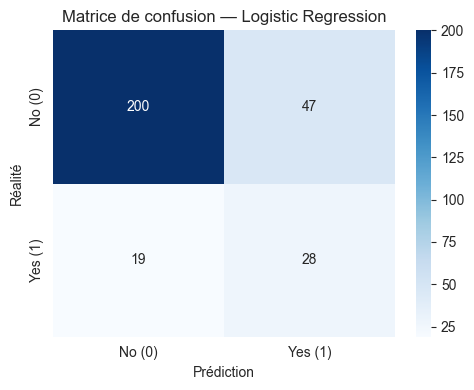

In [12]:
log_reg = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
log_reg = evaluer_modele('Logistic Regression', log_reg, X_train_sm, y_train_sm, X_test_scaled, y_test)

### 3.3 Random Forest

=== Random Forest ===
Accuracy  : 0.8299
Precision : 0.4348
Recall    : 0.2128
F1-score  : 0.2857
AUC-ROC   : 0.7833

Rapport de classification détaillé :
              precision    recall  f1-score   support

      No (0)       0.86      0.95      0.90       247
     Yes (1)       0.43      0.21      0.29        47

    accuracy                           0.83       294
   macro avg       0.65      0.58      0.59       294
weighted avg       0.79      0.83      0.80       294



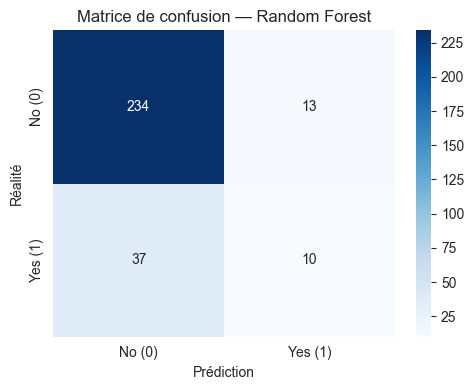

In [13]:
rf = RandomForestClassifier(random_state=RANDOM_STATE)
rf = evaluer_modele('Random Forest', rf, X_train_sm, y_train_sm, X_test_scaled, y_test)

### 3.4 XGBoost

=== XGBoost ===
Accuracy  : 0.8741
Precision : 0.6923
Recall    : 0.3830
F1-score  : 0.4932
AUC-ROC   : 0.7963

Rapport de classification détaillé :
              precision    recall  f1-score   support

      No (0)       0.89      0.97      0.93       247
     Yes (1)       0.69      0.38      0.49        47

    accuracy                           0.87       294
   macro avg       0.79      0.68      0.71       294
weighted avg       0.86      0.87      0.86       294



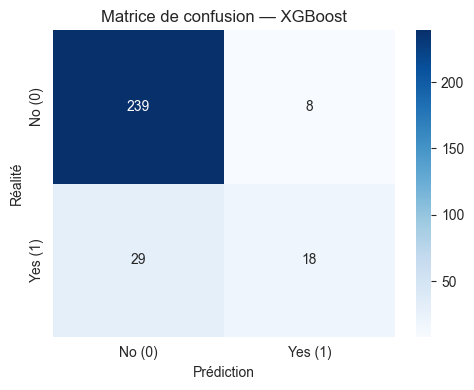

In [14]:
xgb = XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss')
xgb = evaluer_modele('XGBoost', xgb, X_train_sm, y_train_sm, X_test_scaled, y_test)

---
## ÉTAPE 4 — Tableau comparatif final

In [15]:
# Construction du tableau comparatif des 3 modèles
comparaison = pd.DataFrame(resultats).set_index('Modèle').round(4)
comparaison_triee = comparaison.sort_values('F1-score', ascending=False)

print('Tableau comparatif des 3 modèles (trié par F1-score décroissant) :')
comparaison_triee.style.highlight_max(axis=0, color='lightgreen')

Tableau comparatif des 3 modèles (trié par F1-score décroissant) :


,Accuracy,Precision,Recall,F1-score,AUC-ROC
Modèle,,,,,
XGBoost,0.874100,0.692300,0.383000,0.493200,0.796300
Logistic Regression,0.775500,0.373300,0.595700,0.459000,0.785400
Random Forest,0.829900,0.434800,0.212800,0.285700,0.783300


---
## ÉTAPE 5 — Courbes ROC comparatives

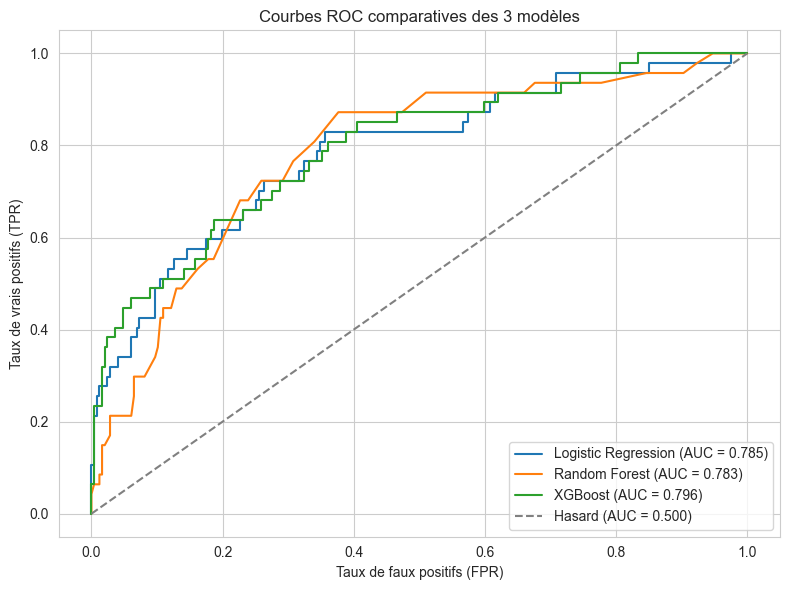

In [16]:
# Courbes ROC des 3 modèles sur un même graphique
plt.figure(figsize=(8, 6))

for nom, (fpr, tpr, auc) in courbes_roc.items():
    plt.plot(fpr, tpr, label=f'{nom} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Hasard (AUC = 0.500)')
plt.xlabel('Taux de faux positifs (FPR)')
plt.ylabel('Taux de vrais positifs (TPR)')
plt.title('Courbes ROC comparatives des 3 modèles')
plt.legend()
plt.tight_layout()
plt.show()

---
## Synthèse des modèles de référence (avant optimisation)

Les résultats ci-dessous correspondent aux modèles entraînés avec leurs **hyperparamètres par défaut** (après SMOTE sur le train). Ils serviront de référence pour mesurer l'apport de l'optimisation réalisée dans les étapes suivantes.

In [17]:
# Identification des meilleurs modèles selon différentes métriques
meilleur_f1 = comparaison['F1-score'].idxmax()
meilleur_recall = comparaison['Recall'].idxmax()
meilleur_auc = comparaison['AUC-ROC'].idxmax()

print('RÉSUMÉ DES RÉSULTATS')
print('=' * 60)
print(comparaison_triee)

print('\n' + '=' * 60)
print(f"Meilleur F1-score      : {meilleur_f1} ({comparaison.loc[meilleur_f1, 'F1-score']:.4f})")
print(f"Meilleur Recall (Yes)  : {meilleur_recall} ({comparaison.loc[meilleur_recall, 'Recall']:.4f})")
print(f"Meilleur AUC-ROC       : {meilleur_auc} ({comparaison.loc[meilleur_auc, 'AUC-ROC']:.4f})")

print('\nConclusion :')
print(f"-> Le modèle '{meilleur_f1}' offre le meilleur compromis precision/recall (F1-score le plus élevé).")
print("-> Le recall sur la classe 'Yes' (départs) est crucial pour ce projet : ")
print('   un faux négatif correspond à un employé à risque non détecté par le modèle.')
print(f"-> Le modèle '{meilleur_recall}' détecte le plus grand nombre de départs réels parmi les 3,")
print('   mais il faut vérifier sa precision pour éviter de multiplier les fausses alertes.')
print(f"-> Le modèle '{meilleur_auc}' présente la meilleure capacité globale à distinguer les deux classes (AUC-ROC).")

RÉSUMÉ DES RÉSULTATS
                     Accuracy  Precision  Recall  F1-score  AUC-ROC
Modèle                                                             
XGBoost                0.8741     0.6923  0.3830    0.4932   0.7963
Logistic Regression    0.7755     0.3733  0.5957    0.4590   0.7854
Random Forest          0.8299     0.4348  0.2128    0.2857   0.7833

Meilleur F1-score      : XGBoost (0.4932)
Meilleur Recall (Yes)  : Logistic Regression (0.5957)
Meilleur AUC-ROC       : XGBoost (0.7963)

Conclusion :
-> Le modèle 'XGBoost' offre le meilleur compromis precision/recall (F1-score le plus élevé).
-> Le recall sur la classe 'Yes' (départs) est crucial pour ce projet : 
   un faux négatif correspond à un employé à risque non détecté par le modèle.
-> Le modèle 'Logistic Regression' détecte le plus grand nombre de départs réels parmi les 3,
   mais il faut vérifier sa precision pour éviter de multiplier les fausses alertes.
-> Le modèle 'XGBoost' présente la meilleure capacité globale

---
## ÉTAPE 6 — Optimisation des hyperparamètres (GridSearchCV / RandomizedSearchCV)

Les modèles de référence (ÉTAPE 3) utilisent leurs hyperparamètres **par défaut**. On cherche maintenant,
pour chacun des 3 modèles, la combinaison d'hyperparamètres qui **maximise le F1-score** (et non l'accuracy,
peu pertinente pour un dataset déséquilibré).

**Méthodologie importante** : pour cette recherche, SMOTE est intégré **à l'intérieur d'un pipeline**
(`imblearn.pipeline.Pipeline`) plutôt qu'appliqué une seule fois sur tout `X_train`. Ainsi, lors de la
validation croisée, SMOTE est recalculé à chaque pli **uniquement à partir des données d'entraînement de
ce pli**, ce qui évite toute fuite d'information vers les données de validation. La recherche est donc
effectuée sur `X_train_scaled` / `y_train` (avant le SMOTE global utilisé en ÉTAPE 3), avec `scoring='f1'`.

Pour **Random Forest** et **XGBoost**, l'espace de recherche inclut également `class_weight` /
`scale_pos_weight`, afin de tester une seconde stratégie de gestion du déséquilibre en complément de SMOTE.

In [18]:
# Outils nécessaires à l'optimisation des hyperparamètres
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import precision_recall_curve
from imblearn.pipeline import Pipeline as ImbPipeline

# Validation croisée stratifiée (reproductible)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Ratio classe majoritaire / classe minoritaire (utile pour scale_pos_weight de XGBoost)
ratio_classes = (y_train == 0).sum() / (y_train == 1).sum()
print(f'Ratio classe majoritaire / minoritaire (train) : {ratio_classes:.2f}')

# Dictionnaire pour stocker les meilleurs modèles trouvés
meilleurs_modeles = {}

Ratio classe majoritaire / minoritaire (train) : 5.19


### 6.1 Logistic Regression — GridSearchCV

In [19]:
# Pipeline SMOTE + Logistic Regression
pipeline_lr = ImbPipeline([
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('clf', LogisticRegression(random_state=RANDOM_STATE, max_iter=2000))
])

# Grille d'hyperparamètres
param_grid_lr = {
    'clf__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'clf__penalty': ['l1', 'l2'],
    'clf__solver': ['liblinear'],
    'clf__class_weight': [None, 'balanced']
}

grid_lr = GridSearchCV(pipeline_lr, param_grid_lr, scoring='f1', cv=cv, n_jobs=-1)
grid_lr.fit(X_train_scaled, y_train)

print('=== Logistic Regression — Optimisation (GridSearchCV) ===')
print(f'Meilleurs hyperparamètres : {grid_lr.best_params_}')
print(f'Meilleur F1-score (validation croisée) : {grid_lr.best_score_:.4f}')

meilleurs_modeles['Logistic Regression'] = grid_lr.best_estimator_

=== Logistic Regression — Optimisation (GridSearchCV) ===
Meilleurs hyperparamètres : {'clf__C': 1, 'clf__class_weight': None, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}
Meilleur F1-score (validation croisée) : 0.5033


C:\Users\jebar\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


### 6.2 Random Forest — RandomizedSearchCV (avec `class_weight`)

In [20]:
# Pipeline SMOTE + Random Forest
pipeline_rf = ImbPipeline([
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('clf', RandomForestClassifier(random_state=RANDOM_STATE))
])

# Espace de recherche d'hyperparamètres (incluant class_weight)
param_dist_rf = {
    'clf__n_estimators': [100, 200, 300, 400],
    'clf__max_depth': [None, 5, 10, 20, 30],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf': [1, 2, 4],
    'clf__class_weight': [None, 'balanced', 'balanced_subsample']
}

random_rf = RandomizedSearchCV(
    pipeline_rf, param_dist_rf, scoring='f1', cv=cv,
    n_iter=25, random_state=RANDOM_STATE, n_jobs=-1
)
random_rf.fit(X_train_scaled, y_train)

print('=== Random Forest — Optimisation (RandomizedSearchCV) ===')
print(f'Meilleurs hyperparamètres : {random_rf.best_params_}')
print(f'Meilleur F1-score (validation croisée) : {random_rf.best_score_:.4f}')

meilleurs_modeles['Random Forest'] = random_rf.best_estimator_

=== Random Forest — Optimisation (RandomizedSearchCV) ===
Meilleurs hyperparamètres : {'clf__n_estimators': 200, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 2, 'clf__max_depth': 5, 'clf__class_weight': 'balanced'}
Meilleur F1-score (validation croisée) : 0.4862


### 6.3 XGBoost — RandomizedSearchCV (avec `scale_pos_weight`)

In [21]:
# Pipeline SMOTE + XGBoost
pipeline_xgb = ImbPipeline([
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('clf', XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss'))
])

# Espace de recherche d'hyperparamètres (incluant scale_pos_weight)
param_dist_xgb = {
    'clf__n_estimators': [100, 200, 300, 400],
    'clf__max_depth': [3, 4, 5, 6, 7],
    'clf__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'clf__subsample': [0.7, 0.8, 1.0],
    'clf__colsample_bytree': [0.7, 0.8, 1.0],
    'clf__scale_pos_weight': [1, ratio_classes]
}

random_xgb = RandomizedSearchCV(
    pipeline_xgb, param_dist_xgb, scoring='f1', cv=cv,
    n_iter=25, random_state=RANDOM_STATE, n_jobs=-1
)
random_xgb.fit(X_train_scaled, y_train)

print('=== XGBoost — Optimisation (RandomizedSearchCV) ===')
print(f'Meilleurs hyperparamètres : {random_xgb.best_params_}')
print(f'Meilleur F1-score (validation croisée) : {random_xgb.best_score_:.4f}')

meilleurs_modeles['XGBoost'] = random_xgb.best_estimator_

=== XGBoost — Optimisation (RandomizedSearchCV) ===
Meilleurs hyperparamètres : {'clf__subsample': 0.8, 'clf__scale_pos_weight': np.float64(5.189473684210526), 'clf__n_estimators': 400, 'clf__max_depth': 5, 'clf__learning_rate': 0.2, 'clf__colsample_bytree': 1.0}
Meilleur F1-score (validation croisée) : 0.5489


---
## ÉTAPE 7 — Optimisation du seuil de décision

Par défaut, un modèle affecte la classe `Yes` (1) si `P(Yes) >= 0.5`. Ce seuil n'est pas nécessairement
optimal pour un problème déséquilibré. Pour chaque modèle optimisé (ÉTAPE 6), on recherche, à partir de la
courbe précision-rappel, le **seuil qui maximise le F1-score sur la classe minoritaire**.

> **Note méthodologique** : par souci de simplicité, le seuil optimal est recherché directement sur
> l'ensemble de test. Dans une démarche plus rigoureuse (hors cadre de ce notebook), ce réglage devrait
> s'appuyer sur un ensemble de validation distinct ou une validation croisée, afin d'éviter toute
> optimisation directe sur les données de test.

In [22]:
# Recherche du seuil optimal (maximisant le F1-score) pour chaque modèle optimisé
seuils_optimaux = {}
probas_test = {}

for nom, modele in meilleurs_modeles.items():
    y_proba = modele.predict_proba(X_test_scaled)[:, 1]
    probas_test[nom] = y_proba

    precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
    f1s = 2 * precisions * recalls / (precisions + recalls + 1e-10)
    meilleur_idx = np.argmax(f1s[:-1])  # le dernier point de la courbe n'a pas de seuil associé
    meilleur_seuil = thresholds[meilleur_idx]
    seuils_optimaux[nom] = meilleur_seuil

    f1_defaut = f1_score(y_test, (y_proba >= 0.5).astype(int))
    f1_optimise = f1_score(y_test, (y_proba >= meilleur_seuil).astype(int))

    print(f'=== {nom} ===')
    print(f'Seuil par défaut (0.50) -> F1 = {f1_defaut:.4f}')
    print(f'Seuil optimal   ({meilleur_seuil:.2f}) -> F1 = {f1_optimise:.4f}')
    print()

=== Logistic Regression ===
Seuil par défaut (0.50) -> F1 = 0.4590
Seuil optimal   (0.66) -> F1 = 0.5049



=== Random Forest ===
Seuil par défaut (0.50) -> F1 = 0.4211
Seuil optimal   (0.39) -> F1 = 0.5180



=== XGBoost ===
Seuil par défaut (0.50) -> F1 = 0.4872
Seuil optimal   (0.41) -> F1 = 0.4938



---
## ÉTAPE 8 — Tableau comparatif final après optimisation

Les métriques sont recalculées avec, pour chaque modèle, ses **hyperparamètres optimisés** (ÉTAPE 6) et son
**seuil de décision optimisé** (ÉTAPE 7).

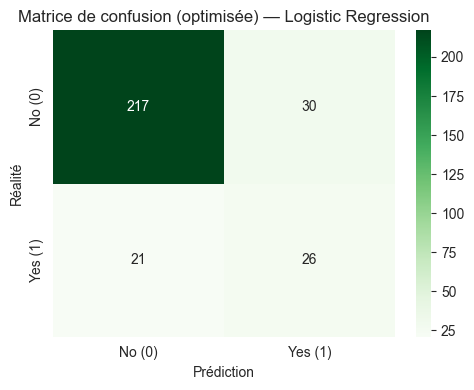

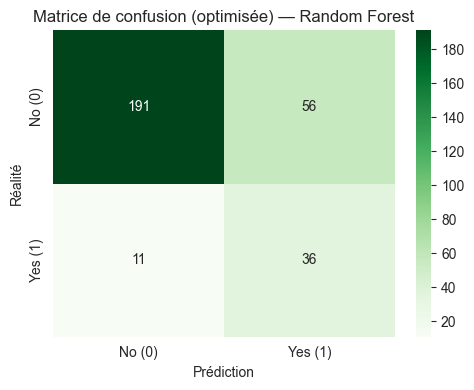

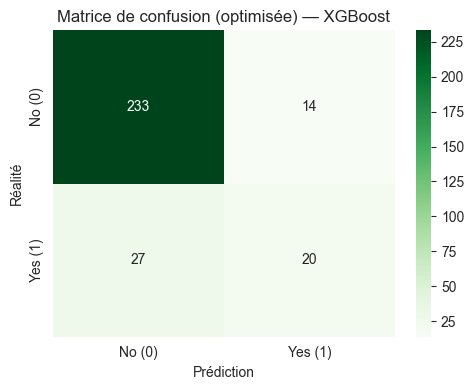

Tableau comparatif des 3 modèles APRÈS optimisation (trié par F1-score décroissant) :


,Accuracy,Precision,Recall,F1-score,AUC-ROC,Seuil optimal
Modèle,,,,,,
Random Forest,0.772100,0.391300,0.766000,0.518000,0.785500,0.388000
Logistic Regression,0.826500,0.464300,0.553200,0.504900,0.785600,0.663000
XGBoost,0.860500,0.588200,0.425500,0.493800,0.794400,0.414000


In [23]:
# Calcul des métriques finales avec hyperparamètres + seuil optimisés
resultats_optimises = []

for nom, modele in meilleurs_modeles.items():
    y_proba = probas_test[nom]
    seuil = seuils_optimaux[nom]
    y_pred = (y_proba >= seuil).astype(int)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    # Matrice de confusion avec le seuil optimisé
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=['No (0)', 'Yes (1)'],
                yticklabels=['No (0)', 'Yes (1)'])
    plt.title(f'Matrice de confusion (optimisée) — {nom}')
    plt.xlabel('Prédiction')
    plt.ylabel('Réalité')
    plt.tight_layout()
    plt.show()

    resultats_optimises.append({
        'Modèle': nom,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-score': f1,
        'AUC-ROC': auc,
        'Seuil optimal': round(float(seuil), 3)
    })

comparaison_opt = pd.DataFrame(resultats_optimises).set_index('Modèle').round(4)
comparaison_opt_triee = comparaison_opt.sort_values('F1-score', ascending=False)

print('Tableau comparatif des 3 modèles APRÈS optimisation (trié par F1-score décroissant) :')
comparaison_opt_triee.style.highlight_max(
    axis=0, subset=['Accuracy', 'Precision', 'Recall', 'F1-score', 'AUC-ROC'], color='lightgreen'
)

### Comparaison avant / après optimisation

In [24]:
# Tableau comparatif avant / après optimisation, côte à côte
comparaison_globale = pd.concat(
    {
        'Avant optimisation': comparaison,
        'Après optimisation': comparaison_opt.drop(columns='Seuil optimal')
    },
    axis=1
)
comparaison_globale

Avant optimisation                                     \
                              Accuracy Precision  Recall F1-score AUC-ROC   
Modèle                                                                      
Logistic Regression             0.7755    0.3733  0.5957   0.4590  0.7854   
Random Forest                   0.8299    0.4348  0.2128   0.2857  0.7833   
XGBoost                         0.8741    0.6923  0.3830   0.4932  0.7963   

                    Après optimisation                                     
                              Accuracy Precision  Recall F1-score AUC-ROC  
Modèle                                                                     
Logistic Regression             0.8265    0.4643  0.5532   0.5049  0.7856  
Random Forest                   0.7721    0.3913  0.7660   0.5180  0.7855  
XGBoost                         0.8605    0.5882  0.4255   0.4938  0.7944

---
## Synthèse finale (après optimisation)

In [25]:
# Identification des meilleurs modèles après optimisation
meilleur_f1_opt = comparaison_opt['F1-score'].idxmax()
meilleur_recall_opt = comparaison_opt['Recall'].idxmax()
meilleur_auc_opt = comparaison_opt['AUC-ROC'].idxmax()

print('RÉSUMÉ — APRÈS OPTIMISATION')
print('=' * 60)
print(comparaison_opt_triee)

print('\n' + '=' * 60)
print(f"Meilleur F1-score      : {meilleur_f1_opt} ({comparaison_opt.loc[meilleur_f1_opt, 'F1-score']:.4f})")
print(f"Meilleur Recall (Yes)  : {meilleur_recall_opt} ({comparaison_opt.loc[meilleur_recall_opt, 'Recall']:.4f})")
print(f"Meilleur AUC-ROC       : {meilleur_auc_opt} ({comparaison_opt.loc[meilleur_auc_opt, 'AUC-ROC']:.4f})")

print('\nGain de F1-score par rapport aux modèles de référence (ÉTAPE 4) :')
for nom in comparaison.index:
    avant = comparaison.loc[nom, 'F1-score']
    apres = comparaison_opt.loc[nom, 'F1-score']
    print(f"  {nom:22s} : {avant:.4f} -> {apres:.4f}  ({apres - avant:+.4f})")

print(f"\nConclusion : le modèle '{meilleur_f1_opt}' est le meilleur choix après optimisation des")
print("hyperparamètres et du seuil de décision (meilleur compromis precision/recall sur la classe")
print("minoritaire, mesuré par le F1-score).")

RÉSUMÉ — APRÈS OPTIMISATION
                     Accuracy  Precision  Recall  F1-score  AUC-ROC  \
Modèle                                                                
Random Forest          0.7721     0.3913  0.7660    0.5180   0.7855   
Logistic Regression    0.8265     0.4643  0.5532    0.5049   0.7856   
XGBoost                0.8605     0.5882  0.4255    0.4938   0.7944   

                     Seuil optimal  
Modèle                              
Random Forest                0.388  
Logistic Regression          0.663  
XGBoost                      0.414  

Meilleur F1-score      : Random Forest (0.5180)
Meilleur Recall (Yes)  : Random Forest (0.7660)
Meilleur AUC-ROC       : XGBoost (0.7944)

Gain de F1-score par rapport aux modèles de référence (ÉTAPE 4) :
  Logistic Regression    : 0.4590 -> 0.5049  (+0.0459)
  Random Forest          : 0.2857 -> 0.5180  (+0.2323)
  XGBoost                : 0.4932 -> 0.4938  (+0.0006)

Conclusion : le modèle 'Random Forest' est le meilleur choi

### Prochaine étape (Notebook 3)

Le notebook suivant portera sur l'**interprétabilité du modèle retenu avec SHAP**, afin d'identifier
les variables qui influencent le plus les prédictions de turnover et de proposer des pistes
d'action concrètes aux équipes RH.